# EECE 6544 — Assignment #03
## WheelsBazaar: Predicting the Fair Market Price of a Used Car

**Business goal.** Replace slow, manual price review with an automated, trustworthy
price estimate so we can (1) flag over-/under-priced listings at scale and
(2) quote a fair buy price for the *WheelsBazaar Direct* instant-buy program.

**ML framing.** This is a **supervised regression** problem: predict the continuous
target `Price` (₹) from a car's attributes. We build a clean feature pipeline,
compare a linear baseline against a gradient-boosted model, evaluate on a held-out
test set, and translate the results back into business decisions.

In [1]:
!pip install scikit-learn pandas numpy matplotlib

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## 1. Load and inspect the data
The dataset (`car details v4.csv`) holds 2,059 used-car listings with 20 columns:
identity (`Make`, `Model`), the target (`Price`), and attributes covering age,
usage, powertrain, and body dimensions.

In [3]:
df = pd.read_csv("car details v4.csv")
print("Shape:", df.shape)
df.head()

Shape: (2059, 20)


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [4]:
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Make                   object
Model                  object
Price                   int64
Year                    int64
Kilometer               int64
Fuel Type              object
Transmission           object
Location               object
Color                  object
Owner                  object
Seller Type            object
Engine                 object
Max Power              object
Max Torque             object
Drivetrain             object
Length                float64
Width                 float64
Height                float64
Seating Capacity      float64
Fuel Tank Capacity    float64
dtype: object

Missing values per column:
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64


In [5]:
# The target is heavily right-skewed (a few luxury cars dominate the tail).
print(df["Price"].describe().apply(lambda v: f"{v:,.0f}"))

count         2,059
mean      1,702,992
std       2,419,881
min          49,000
25%         484,999
50%         825,000
75%       1,925,000
max      35,000,000
Name: Price, dtype: object


### The target is skewed → model `log(Price)`
Price spans ₹49k to ₹35M. Prices this skewed make a linear model chase the luxury
outliers and hurt accuracy on the bulk of ordinary cars. We train on
`log1p(Price)` and invert (`expm1`) for reporting, so errors are judged on the
real rupee scale.

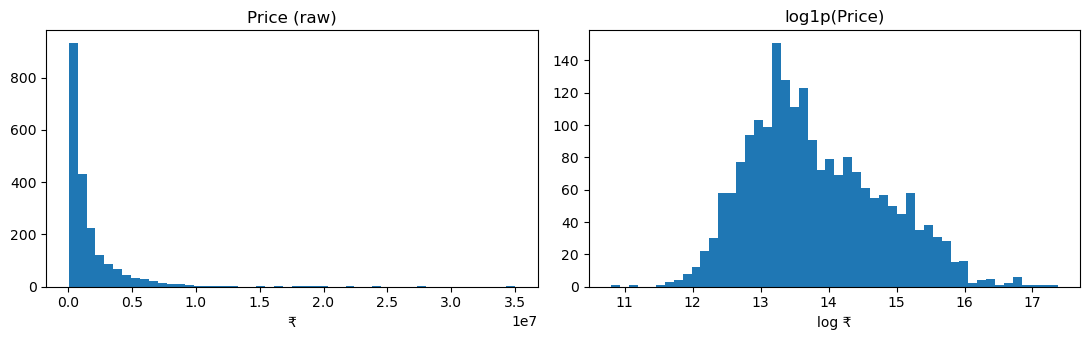

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df["Price"], bins=50); ax[0].set_title("Price (raw)"); ax[0].set_xlabel("₹")
ax[1].hist(np.log1p(df["Price"]), bins=50); ax[1].set_title("log1p(Price)"); ax[1].set_xlabel("log ₹")
plt.tight_layout(); plt.show()

## 2. Clean and engineer features
Three columns hide numbers inside text, and one is a raw calendar year:

- `Engine` → `1198 cc` → **engine_cc**
- `Max Power` → `87 bhp @ 6000 rpm` → **power_bhp**
- `Max Torque` → `109 Nm @ 4500 rpm` → **torque_nm**
- `Year` → **age** = 2022 − Year  (buyers care about age, not the calendar year)

We also collapse the long tail of rare fuel types (Electric, LPG, Hybrid, dual-fuel)
into a single `Other` bucket so one-hot encoding stays compact.

In [7]:
def extract_number(series, pattern):
    """Pull the first numeric group matching `pattern` out of a text column."""
    def parse(x):
        if pd.isna(x):
            return np.nan
        m = re.search(pattern, str(x))
        return float(m.group(1)) if m else np.nan
    return series.map(parse)

df["engine_cc"] = extract_number(df["Engine"],    r"([\d.]+)")
df["power_bhp"] = extract_number(df["Max Power"],  r"([\d.]+)\s*bhp")
df["torque_nm"] = extract_number(df["Max Torque"], r"([\d.]+)\s*Nm")

REFERENCE_YEAR = 2022  # newest listing year in the data ≈ "today"
df["age"] = REFERENCE_YEAR - df["Year"]

# collapse rare fuel types into "Other"
common_fuels = ["Diesel", "Petrol", "CNG"]
df["Fuel Type"] = df["Fuel Type"].where(df["Fuel Type"].isin(common_fuels), "Other")

df[["Engine", "engine_cc", "Max Power", "power_bhp", "Max Torque", "torque_nm", "Year", "age"]].head()

,Engine,engine_cc,Max Power,power_bhp,Max Torque,torque_nm,Year,age
0,1198 cc,1198.0,87 bhp @ 6000 rpm,87.0,109 Nm @ 4500 rpm,109.0000,2017,5
1,1248 cc,1248.0,74 bhp @ 4000 rpm,74.0,190 Nm @ 2000 rpm,190.0000,2014,8
2,1197 cc,1197.0,79 bhp @ 6000 rpm,79.0,112.7619 Nm @ 4000 rpm,112.7619,2011,11
3,1197 cc,1197.0,82 bhp @ 6000 rpm,82.0,113 Nm @ 4200 rpm,113.0000,2019,3
4,2393 cc,2393.0,148 bhp @ 3400 rpm,148.0,343 Nm @ 1400 rpm,343.0000,2018,4


## 3. Define predictors and target
**Numeric** features go through median-imputation + scaling. **Categorical**
features go through most-frequent-imputation + one-hot encoding.

We deliberately drop `Model` (1,050 unique values → too sparse to one-hot),
`Location` and `Color` (little price signal, high cardinality). `Make` plus the
engineered engine/power/size features carry the model-level information.

In [8]:
num_feats = ["age", "Kilometer", "engine_cc", "power_bhp", "torque_nm",
             "Length", "Width", "Height", "Seating Capacity", "Fuel Tank Capacity"]
cat_feats = ["Make", "Fuel Type", "Transmission", "Owner", "Seller Type", "Drivetrain"]

X = df[num_feats + cat_feats]
y = np.log1p(df["Price"])          # model the log-price
print("Predictors:", len(num_feats), "numeric +", len(cat_feats), "categorical")
print("X shape:", X.shape, "| y shape:", y.shape)

Predictors: 10 numeric + 6 categorical
X shape: (2059, 16) | y shape: (2059,)


## 4. Split the data
80/20 train/test split with a fixed seed for reproducibility. The model never
sees the test cars during training.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 1647 | Test: 412


## 5. Build the preprocessing + model pipeline
Wrapping everything in a `Pipeline` guarantees that imputation, scaling, and
encoding are **fit on the training data only** — no leakage from the test set.

In [10]:
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
    ]), num_feats),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_feats),
])

## 6. Fit and compare models
We evaluate three models on the **same split**, always reporting metrics on the
real rupee scale (invert the log before scoring):

1. **Naive baseline** — always predict the mean price.
2. **Linear regression** — a transparent, interpretable floor.
3. **Gradient boosting** — captures the non-linear interactions (a 10-year-old
   luxury car and a 10-year-old hatchback depreciate very differently).

In [11]:
def evaluate(name, model):
    model.fit(X_train, y_train)
    pred = np.expm1(model.predict(X_test))     # back to ₹
    true = np.expm1(y_test)
    r2   = r2_score(true, pred)
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((pred - true) / true)) * 100
    print(f"{name:20}  R2={r2:.3f}  MAE=₹{mae:,.0f}  RMSE=₹{rmse:,.0f}  MAPE={mape:.1f}%")
    return model, pred, true

# 1. Naive baseline
naive_pred = np.full(len(y_test), np.expm1(y_train).mean())
print(f"{'Naive (mean price)':20}  R2={r2_score(np.expm1(y_test), naive_pred):.3f}"
      f"  MAE=₹{mean_absolute_error(np.expm1(y_test), naive_pred):,.0f}")

# 2. Linear regression
lin_model, _, _ = evaluate("Linear regression",
    Pipeline([("prep", preprocess), ("reg", LinearRegression())]))

# 3. Gradient boosting
gb_model, gb_pred, gb_true = evaluate("Gradient boosting",
    Pipeline([("prep", preprocess),
              ("reg", GradientBoostingRegressor(
                  n_estimators=400, max_depth=3, learning_rate=0.05,
                  random_state=RANDOM_STATE))]))

Naive (mean price)    R2=-0.000  MAE=₹1,454,531


Linear regression     R2=0.689  MAE=₹330,411  RMSE=₹1,473,917  MAPE=16.1%


Gradient boosting     R2=0.898  MAE=₹280,971  RMSE=₹843,413  MAPE=15.1%


### Cross-validation check
5-fold CV (on log-price R²) confirms the boosted model's performance is stable
and not an artifact of the single test split.

In [12]:
cv = cross_val_score(gb_model, X, y, cv=5, scoring="r2")
print(f"Gradient boosting 5-fold R² (log scale): {cv.mean():.3f} ± {cv.std():.3f}")

Gradient boosting 5-fold R² (log scale): 0.941 ± 0.016


## 7. What drives the price?
Gradient-boosting feature importances show which attributes the model relies on.

num__power_bhp                 0.541747
num__age                       0.128016
num__Width                     0.085703
num__torque_nm                 0.061585
cat__Transmission_Manual       0.047376
cat__Transmission_Automatic    0.039562
num__Length                    0.021850
num__Kilometer                 0.013385
num__Fuel Tank Capacity        0.010769
cat__Drivetrain_FWD            0.007235
cat__Make_Mercedes-Benz        0.007231
num__engine_cc                 0.006837


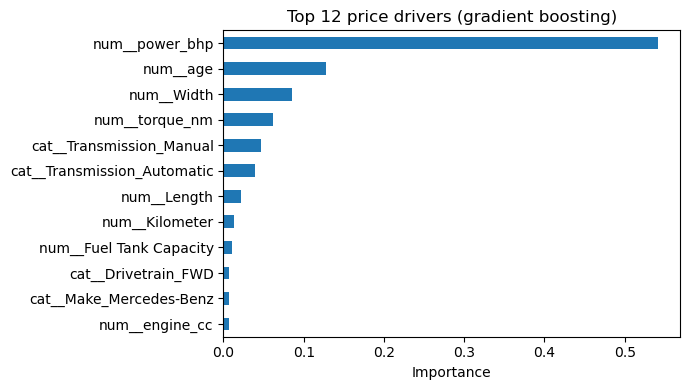

In [13]:
feat_names = gb_model.named_steps["prep"].get_feature_names_out()
importances = (pd.Series(gb_model.named_steps["reg"].feature_importances_, index=feat_names)
                 .sort_values(ascending=False))
top = importances.head(12)
print(top.to_string())

plt.figure(figsize=(7, 4))
top[::-1].plot(kind="barh")
plt.title("Top 12 price drivers (gradient boosting)")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

## 8. Prediction accuracy, visualized
Predicted vs. actual price on the held-out test set. Points hug the diagonal;
the model tracks price across three orders of magnitude.

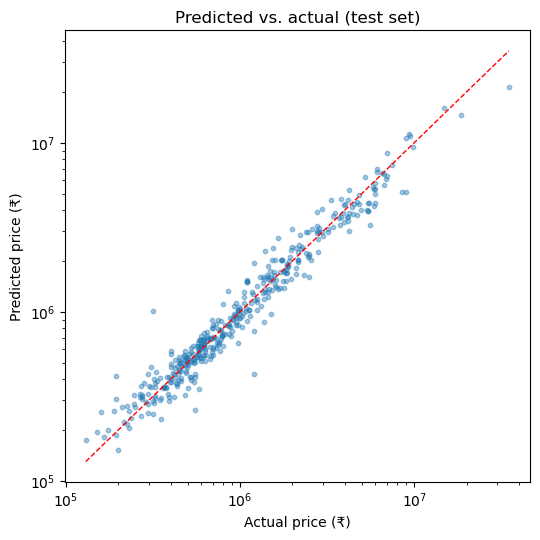

In [14]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(gb_true, gb_pred, s=10, alpha=0.4)
lims = [gb_true.min(), gb_true.max()]
plt.plot(lims, lims, "r--", lw=1)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Actual price (₹)"); plt.ylabel("Predicted price (₹)")
plt.title("Predicted vs. actual (test set)")
plt.tight_layout(); plt.show()

## 9. Turn predictions into business decisions
### 9a. Fair-price quote for *WheelsBazaar Direct*
For any new car, the model returns an instant fair-price estimate.

In [15]:
def build_row(**kw):
    return pd.DataFrame([kw])[num_feats + cat_feats]

example_car = build_row(
    age=REFERENCE_YEAR - 2018, Kilometer=45000, engine_cc=1197, power_bhp=82,
    torque_nm=113, Length=3995, Width=1734, Height=1500,
    **{"Seating Capacity": 5, "Fuel Tank Capacity": 37},
    Make="Hyundai", **{"Fuel Type": "Petrol"}, Transmission="Manual",
    Owner="First", **{"Seller Type": "Individual"}, Drivetrain="FWD")

quote = np.expm1(gb_model.predict(example_car))[0]
print("Car: 2018 Hyundai petrol hatchback, 45,000 km, first owner, manual")
print(f"Fair-price estimate: ₹{quote:,.0f}")

Car: 2018 Hyundai petrol hatchback, 45,000 km, first owner, manual
Fair-price estimate: ₹664,862


### 9b. Flag over- and under-priced listings
The core operations use-case: compare each seller's asking price to the model's
estimate. Listings **>15% above** the estimate are *overpriced* (they sit unsold);
listings **>15% below** are *underpriced* (sellers lose money). Everything in
between is *fair*. This lets analysts triage the whole 5,000/month inventory
instead of hand-reviewing <25% of it.

In [16]:
def price_flag(asking, estimate, tol=0.15):
    diff = (asking - estimate) / estimate
    if diff > tol:  return "OVERPRICED"
    if diff < -tol: return "UNDERPRICED"
    return "fair"

# Apply to the test set: treat the listed Price as the "asking" price.
test_est = np.expm1(gb_model.predict(X_test))
test_ask = np.expm1(y_test).values
flags = [price_flag(a, e) for a, e in zip(test_ask, test_est)]
print(pd.Series(flags).value_counts())
print(f"\nShare of listings the model would auto-clear as 'fair': "
      f"{(pd.Series(flags) == 'fair').mean() * 100:.0f}%")

fair           265
OVERPRICED      83
UNDERPRICED     64
Name: count, dtype: int64

Share of listings the model would auto-clear as 'fair': 64%


## 10. Summary
- **Model:** gradient-boosted regression on `log(Price)` with a leakage-safe
  preprocessing pipeline (median/most-frequent imputation, scaling, one-hot).
- **Accuracy:** R² ≈ 0.90 on held-out data — a large lift over the linear
  baseline (R² ≈ 0.69) and the naive mean (R² ≈ 0).
- **Key drivers:** engine power (`power_bhp`) dominates, followed by age, body
  size, torque, and transmission — matching real-world used-car intuition.
- **Business value:** every listing gets an instant fair-price estimate, feeding
  both the over/under-priced triage workflow and the *WheelsBazaar Direct*
  buy-price quote — turning a manual <25%-coverage review into full automation.